# Demo of fetching XRR data from Tiled 

To install tiled, do 

    pip install tiled[all] matplotlib

in whatever environment you use for these things.  I generally use either venv or pixi and can help with either of those.  Note that the conda packages for Tiled might not be be up to date.

Import the `from_uri` method, then connect to BMM's database.  This step will involve an authentication.  The result of the authentication is that you will only have access to data associated with proposals that you are on.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from tiled.client import from_uri
client = from_uri('https://tiled.nsls2.bnl.gov/api/v1/metadata/bmm/migration')

I will use a specific XRR run for the first part of the demo.  Later, I will show you how to find other records containing XRR spectra.

The following will slurp a record into an xarray.  This is a bit inefficient up front, as it will also load the entire stack of Mythen MCA spectra into the xarray.  But the Mythen doesn't make that much data.  Preloading is not all that inefficient and will speed steps up in later steps.

In [2]:
uid = 'eeea9606-ddfc-46a6-8431-bdd9f5e39631'
xa=client[uid]['primary'].read()

You can look at the full xarray, or at a few salient parts

In [3]:
xa

<xarray.Dataset> Size: 1MB
Dimensions:                          (time: 251, mythen-2_image_dim1: 1,
                                      mythen-2_image_dim2: 1280)
Coordinates:
  * time                             (time) float64 2kB 1.791e+09 ... 1.791e+09
Dimensions without coordinates: mythen-2_image_dim1, mythen-2_image_dim2
Data variables: (12/14)
    mca_full                         (time) float64 2kB 6.402e+04 ... 444.0
    eta                              (time) float64 2kB 0.0 0.02 ... 4.98 5.0
    refl                             (time) float64 2kB 6.318e+04 ... 92.0
    dwti_dwell_time_setpoint         (time) float64 2kB 1.0 1.0 1.0 ... 1.0 1.0
    attenuator_attenuation_setpoint  (time) int64 2kB 5 5 5 5 6 6 ... 0 0 0 0 0
    monitor                          (time) float64 2kB 1.704e+04 ... 1.633e+04
    ...                               ...
    dwti_dwell_time                  (time) float64 2kB 1.0 1.0 1.0 ... 1.0 1.0
    delta_user_setpoint              (time) float64 2kB 0.0 0.04 ... 9.96 10.0
    eta_user_setpoint                (time) float64 2kB 0.0 0.02 ... 4.98 5.0
    attenuator_attenuation           (time) int64 2kB 5 5 5 5 6 6 ... 0 0 0 0 0
    max_counts                       (time) float64 2kB 3.008e+04 ... 22.0
    mythen-2_image                   (time, mythen-2_image_dim1, mythen-2_image_dim2) uint32 1MB ...

In [4]:
xa['eta']  # this returns an array of eta positions

<xarray.DataArray 'eta' (time: 251)> Size: 2kB
array([0.  , 0.02, 0.04, 0.06, 0.08, 0.1 , 0.12, 0.14, 0.16, 0.18, 0.2 ,
       0.22, 0.24, 0.26, 0.28, 0.3 , 0.32, 0.34, 0.36, 0.38, 0.4 , 0.42,
       0.44, 0.46, 0.48, 0.5 , 0.52, 0.54, 0.56, 0.58, 0.6 , 0.62, 0.64,
       0.66, 0.68, 0.7 , 0.72, 0.74, 0.76, 0.78, 0.8 , 0.82, 0.84, 0.86,
       0.88, 0.9 , 0.92, 0.94, 0.96, 0.98, 1.  , 1.02, 1.04, 1.06, 1.08,
       1.1 , 1.12, 1.14, 1.16, 1.18, 1.2 , 1.22, 1.24, 1.26, 1.28, 1.3 ,
       1.32, 1.34, 1.36, 1.38, 1.4 , 1.42, 1.44, 1.46, 1.48, 1.5 , 1.52,
       1.54, 1.56, 1.58, 1.6 , 1.62, 1.64, 1.66, 1.68, 1.7 , 1.72, 1.74,
       1.76, 1.78, 1.8 , 1.82, 1.84, 1.86, 1.88, 1.9 , 1.92, 1.94, 1.96,
       1.98, 2.  , 2.02, 2.04, 2.06, 2.08, 2.1 , 2.12, 2.14, 2.16, 2.18,
       2.2 , 2.22, 2.24, 2.26, 2.28, 2.3 , 2.32, 2.34, 2.36, 2.38, 2.4 ,
       2.42, 2.44, 2.46, 2.48, 2.5 , 2.52, 2.54, 2.56, 2.58, 2.6 , 2.62,
       2.64, 2.66, 2.68, 2.7 , 2.72, 2.74, 2.76, 2.78, 2.8 , 2.82, 2.84,
       2.86, 2.88, 2.9 , 2.92, 2.94, 2.96, 2.98, 3.  , 3.02, 3.04, 3.06,
       3.08, 3.1 , 3.12, 3.14, 3.16, 3.18, 3.2 , 3.22, 3.24, 3.26, 3.28,
       3.3 , 3.32, 3.34, 3.36, 3.38, 3.4 , 3.42, 3.44, 3.46, 3.48, 3.5 ,
       3.52, 3.54, 3.56, 3.58, 3.6 , 3.62, 3.64, 3.66, 3.68, 3.7 , 3.72,
       3.74, 3.76, 3.78, 3.8 , 3.82, 3.84, 3.86, 3.88, 3.9 , 3.92, 3.94,
       3.96, 3.98, 4.  , 4.02, 4.04, 4.06, 4.08, 4.1 , 4.12, 4.14, 4.16,
       4.18, 4.2 , 4.22, 4.24, 4.26, 4.28, 4.3 , 4.32, 4.34, 4.36, 4.38,
       4.4 , 4.42, 4.44, 4.46, 4.48, 4.5 , 4.52, 4.54, 4.56, 4.58, 4.6 ,
       4.62, 4.64, 4.66, 4.68, 4.7 , 4.72, 4.74, 4.76, 4.78, 4.8 , 4.82,
       4.84, 4.86, 4.88, 4.9 , 4.92, 4.94, 4.96, 4.98, 5.  ])
Coordinates:
  * time     (time) float64 2kB 1.791e+09 1.791e+09 ... 1.791e+09 1.791e+09

Try looking at `xa['mythen-2_image']` to see how a multi-dimensional array is presented.

Let's do something simple with the record.  Here is a plot of the signal in the `refl` ROI as a function of `eta`.

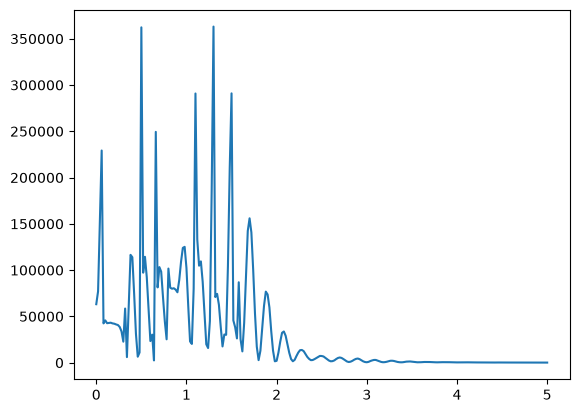

In [5]:
plt.plot(xa['eta'], xa['refl'])

## Metadata

There is A LOT of metadata attached to the record.  Here is how you find it.  

In [6]:
client[uid].metadata

{'start': {'XDI': {'Beamline': {'attenuators': '[1, 6.85865, 47.0366217, '
                                               '322.57715161859994, '
                                               '2246.4272838719303, '
                                               '15644.119604884123, '
                                               '109211.59896169606]',
                                'collimation': 'paraboloid mirror, 5 nm Rh on '
                                               '30 nm Pt',
                                'endstation': '6+2 circle psi goniometer',
                                'eta_refinement': [{'attenuator': 2,
                                                    'delta': 1.9999499999999983,
                                                    'diff': -0.0012499999999999734,
                                                    'eta_found': 1.00125,
                                                    'eta_nominal': 1,
                                                    '

Notes on the metadata:
* The `['start']['XDI']['Beamline']['attenuators']` element has a list of attenuator values that can be used to reduce the data, that is, I attach those numbers to every record.  That said, I think I did that after you left, so the records with data on your samples probably do not have that attached to their metadata.
* The `['start']['plan_name']` element of the metadata is `scan_nd xrr`. We will use this to find other examples of XRR scans.

The metadata attached to the XRR measurement is a work in progress.  Future measurements will have more stuff attached to the metadata to enable the writing of interesting reports on each measurement.

## Plotting an XRR spectrum

This requires a bit of wrangling to convert an array of attenuator settings to an array of attenuation values, then we can construct the XRR out of columns of the xarray.

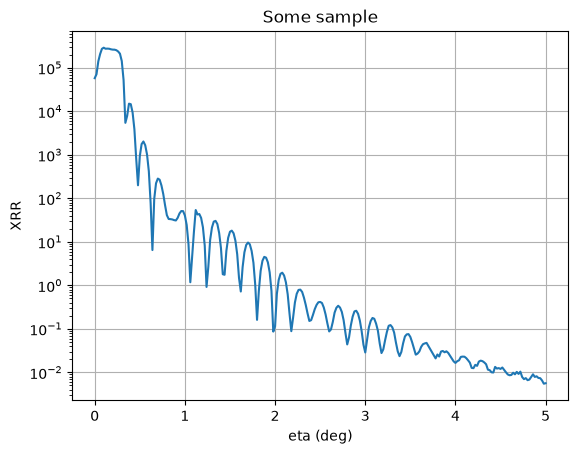

In [7]:
from ast import literal_eval
def plot_one_scan(uid):
    xa=client[uid]['primary'].read()
    try:
        # at some point, I started putting the attenuation terms in the metadata as a stringified list
        attenuation_factors = np.array(literal_eval(client[uid].metadata['start']['XDI']['Beamline']['attenuators']))
    except:
        # for those records measured earlier, here are other numbers
        attenuation_factors = np.array([1, 6.85865,  # 0 1
                                        6.85865*6.858,  # 2
                                        6.85865*6.858*6.858,  # 3
                                        6.85865*6.858*6.858*6.964,  # 4
                                        6.85865*6.858*6.858*6.964*6.964,  # 5
                                        6.85865*6.858*6.858*6.964*6.964*6.981,  # 6
                                       ])
    factor = attenuation_factors[xa['attenuator_attenuation']]
    xrr = factor * (xa['refl'] / xa['monitor']) / xa['dwti_dwell_time']
    fig, ax = plt.subplots()
    plt.plot(xa['eta'], xrr)
    ax.set_title('Some sample')
    ax.set_yscale('log')
    ax.set_ylabel('XRR')
    ax.set_xlabel('eta (deg)')
    ax.grid()

plot_one_scan(uid)

## Searching for records

XRR scans can be identified by the `plan_name` in the start document.  The `Key` method knows how to dig through the nested dictionary of the metadata to find specific entries.  `plan_name` is in the `start` portion of the metadata, so we set up a Key search as shown in the next box.  I then show an example of refining that search to include only those scans with a large number of datapoints.  See https://blueskyproject.io/tiled/reference/queries.html and https://blueskyproject.io/tiled/getting-started/10-minutes-to-tiled.html for lots more details.

In [8]:
from tiled.queries import Key
spn=Key('start.plan_name')
xrrscans = client.search(spn=='scan_nd xrr')
long_xrrscans = xrrscans.search(Key('stop.num_events.primary') > 450)
long_xrrscans

<Catalog {269, 318, 398, 512, 517, 518}>

# Finding UID strings

Once you have a catalog of relevant records, there are a number of ways of finding UID strings.  Maybe the simplest if cast the catalog into a list.  This list is a list of UID strings.

In [9]:
list(long_xrrscans)

['3884d04a-c9a3-458d-ad15-8f208d857e36',
 '5125c1d7-0dac-4039-9a77-4b7679391e85',
 'd72f900d-2373-4d60-95fe-39ce6d779045',
 '202813a6-ee07-4a8f-b583-3b0699d7c5d4',
 '503d8dc0-78a4-4d7a-9ddb-02f16717c3bf',
 '160f749c-6492-422f-80e4-0cf536265ec0']

You can fetch the UID from a single entry like so, which finds the UIDs string for the last item in that catalog:

In [10]:
long_xrrscans[-1].metadata['start']['uid']

'160f749c-6492-422f-80e4-0cf536265ec0'

UID strings are obviously clunky for humans.  There are a couple things that make working with them easier:

1. Attaching sample-specific metadata to a measurement makes it possible to limit a seach to just the records of interest.  This limits the number of clunky UID strings to interact with
2. You can use partial strings.  For example, this will work:

In [29]:
client['160f749c']

<BlueskyRun v3.0 streams: {'baseline', 'primary'} scan_id=518 uid='160f749c' 2026-09-28 12:58>

But notice how slow that is.  Tiled has to search the entire database to figure out a plausible match for that partial UID string.  A partial string has to have at least 6 characters to have enough entropy to guarantee a unique match.

A useful idiom is to do

     uid = long_xrrscans['160f749c'].metadata['start']['uid']

to get the full uid, then use the full UID going forward.

## Finding data by sample name

A thing that will be worked on in the coming weeks is the definition of a new expriment.  That is, the user will somehow be prompted to supply things like a filename stub, the sample stoichiometry or composition, and other details about its fabrication and preparation.  All that will also be stored in the metadata.  Thus, it will soon be possible to find scans like so:

In [11]:
spn=Key('start.plan_name')
xrrscans = client.search(spn=='scan_nd xrr')
desired_records = xrrscans.search(Key('start.XDI.Sample.name') == 'test_sample')
## i.e. the provided name of the sample / the filename stub will be stored in that metadata entry
## this will be the same catalog of records as simply searching on the plan_name because every sample was
## called "test_sample" in the metadata during our commisioning time.  Capturing this kind of metadata
## in an actionable way is near-future project
desired_records

<Catalog {231, 232, 233, 234, 235, 236, 237, 238, 239, 240, ...} ~154 entries>

## Finding UIDs from exported file

Some of the files written by the control system have the UID of the scan among the text of the file.  For example, at the sftp site, in the proposal folder, you will find files like `wheel5_time1.xdi`. (This was one of the scans made to look into the thicknesses of the attenuators.)  Among the header of that file is a line like

     # Scan.uid: e01ca726-4610-4755-b410-8ce5890c13a4

That, then, is a UID that can be used in Tiled.  In fact, I will do just that below.

# The baseline stream

You may have noticed that a BlueskyRun has two "streams" associated with it, primary and baseline.  The primary stream is the portion of the record containing the measured, scientific data.

The baseline is used at BMM to record the state of the rest of the beamline.  It is configured to record the positions of every motor on the goniometer and every motor in the photon delivery system just before the beginning of the scan and just after the end of the scan.  that is, it captures all those motor positions twice. Thus, there is a quantifiable record of the state of the beamline associated with every scan.

So, a question like "What were the slit sizes for this scan?" can always be answered.  Do something like this:

In [13]:
bl = client[uid].baseline.read()
si=bl['slits_i'][0]
so=bl['slits_o'][0]
st=bl['slits_t'][0]
sb=bl['slits_b'][0]
print(f'Slit dimensions: {si+so:.2f} mm horizontal by {st+sb:.2f} mm vertical')

Slit dimensions: 1.00 mm horizontal by 0.12 mm vertical


Note that each entry in the baseline returns a 2-element array. This is because the baseline stream is filled at the *beginning* and at the *end* of the scan.

# Examining data

Armed with access to Tiled and a way of finding UIDs of relevant records, we can plot stuff!

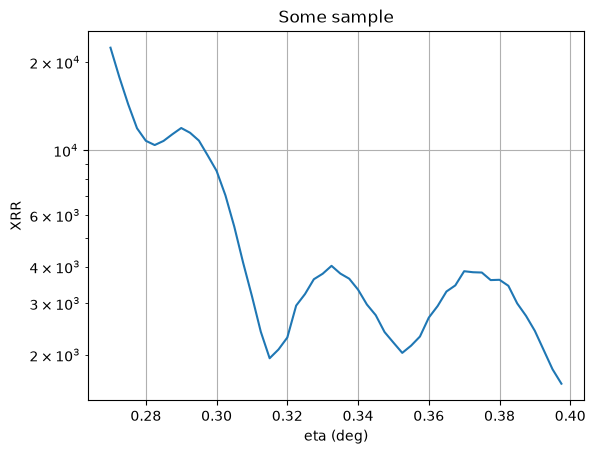

In [16]:
this_uid = 'e01ca726-4610-4755-b410-8ce5890c13a4' # this is the UID extracted from one of the text files
plot_one_scan(this_uid)